# Cognifyz Data Science Internship Tasks
This notebook covers Level 1, Level 2, and Level 3 tasks.

In [23]:
# ===========================
# 📦 Import Required Libraries
# ===========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Show plots inline
%matplotlib inline

In [24]:
# ===========================
# 📂 Load Dataset
# ===========================
# Replace 'Dataset .csv' with your dataset file
df = pd.read_csv("Dataset.csv")
df.head()

,aggregate_rating,cuisines,city,country_code,latitude,longitude,average_cost_for_two,has_table_booking,has_online_delivery,price_range,...,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,name_length,address_length,num_cuisines,primary_cuisine
0,4.8,"French, Japanese, Desserts",Makati City,162,14.565443,121.027535,1100,1,0,3,...,No,3,4.8,Dark Green,Excellent,314,16,71,3,French
1,4.5,Japanese,Makati City,162,14.553708,121.014101,1200,1,0,3,...,No,3,4.5,Dark Green,Excellent,591,16,67,1,Japanese
2,4.4,"Seafood, Asian, Filipino, Indian",Mandaluyong City,162,14.581404,121.056831,4000,1,0,4,...,No,4,4.4,Green,Very Good,270,22,56,4,Seafood
3,4.9,"Japanese, Sushi",Mandaluyong City,162,14.585318,121.056475,1500,0,0,4,...,No,4,4.9,Dark Green,Excellent,365,4,70,2,Japanese
4,4.8,"Japanese, Korean",Mandaluyong City,162,14.584450,121.057508,1500,1,0,4,...,No,4,4.8,Dark Green,Excellent,229,11,64,2,Japanese


# 🔹 Level 1 Tasks: Data Exploration & Descriptive Analysis

In [25]:
# Task 1: Data Exploration and Preprocessing
print("Shape of dataset:", df.shape)
print("Missing values per column:\n", df.isnull().sum())
df.info()

Shape of dataset: (9551, 38)
Missing values per column:
 aggregate_rating        0
cuisines                9
city                    0
country_code            0
latitude                0
longitude               0
average_cost_for_two    0
has_table_booking       0
has_online_delivery     0
price_range             0
name                    0
address                 0
votes                   0
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
name_length             0
address_length          0
num_cui

In [26]:
# Handle missing values (basic strategy)
for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in df.select_dtypes(include=["object"]).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\drman\AppData\Local\Temp\ipykernel_27860\1897701415.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\drman\AppData\Local\Temp\ipykernel_27860\1897701415.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

       aggregate_rating  country_code     latitude    longitude  \
count       9551.000000   9551.000000  9551.000000  9551.000000   
mean           2.666370     18.365616    25.854381    64.126574   
std            1.516378     56.750546    11.007935    41.467058   
min            0.000000      1.000000   -41.330428  -157.948486   
25%            2.500000      1.000000    28.478713    77.081343   
50%            3.200000      1.000000    28.570469    77.191964   
75%            3.700000      1.000000    28.642758    77.282006   
max            4.900000    216.000000    55.976980   174.832089   

       average_cost_for_two  has_table_booking  has_online_delivery  \
count           9551.000000        9551.000000          9551.000000   
mean            1199.210763           0.121244             0.256622   
std            16121.183073           0.326428             0.436792   
min                0.000000           0.000000             0.000000   
25%              250.000000           0.0

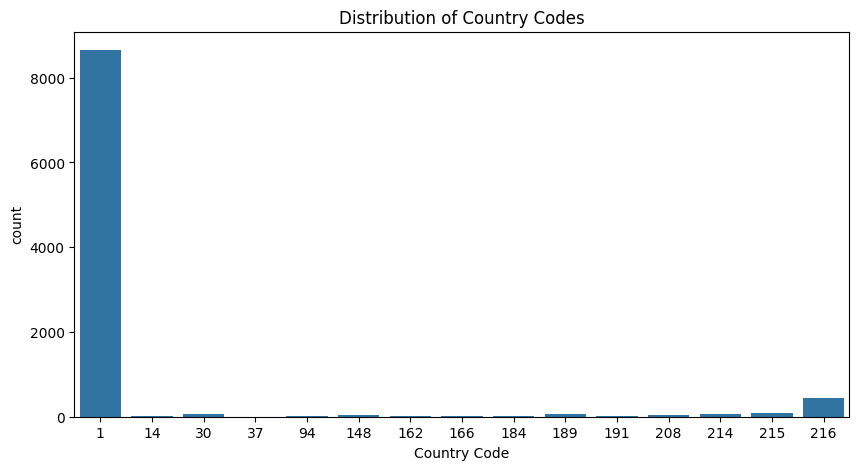

In [27]:
# Task 2: Descriptive Analysis
print(df.describe())

if "Country Code" in df.columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x="Country Code")
    plt.title("Distribution of Country Codes")
    plt.show()

# 🔹 Level 2 Tasks: Business Analysis & Feature Engineering

In [28]:
# Task 1: Table Booking and Online Delivery
if "Has Table booking" in df.columns:
    print("Table booking availability (%):")
    print(df["Has Table booking"].value_counts(normalize=True) * 100)

if "Has Online delivery" in df.columns:
    print("\nOnline delivery availability (%):")
    print(df["Has Online delivery"].value_counts(normalize=True) * 100)

Table booking availability (%):
Has Table booking
No     87.875615
Yes    12.124385
Name: proportion, dtype: float64

Online delivery availability (%):
Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64
Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


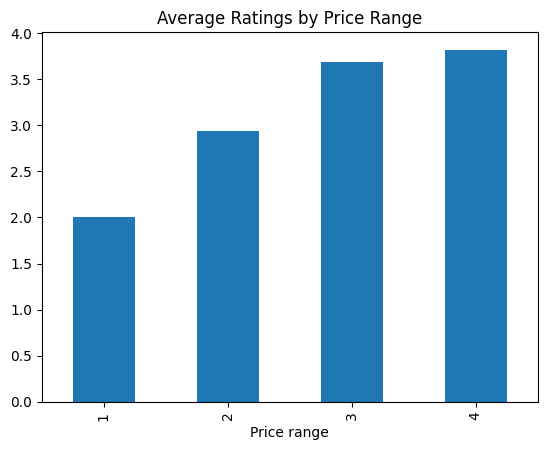

In [29]:
# Task 2: Price Range Analysis
if "Price range" in df.columns and "Aggregate rating" in df.columns:
    print(df["Price range"].value_counts())
    avg_ratings = df.groupby("Price range")["Aggregate rating"].mean()
    print(avg_ratings)
    avg_ratings.plot(kind="bar", title="Average Ratings by Price Range")
    plt.show()

In [30]:
# Task 3: Feature Engineering Example
if "Restaurant Name" in df.columns:
    df["Restaurant Name Length"] = df["Restaurant Name"].apply(lambda x: len(str(x)))

if "Has Table booking" in df.columns:
    df["Has Table Booking (Encoded)"] = df["Has Table booking"].map({"Yes":1, "No":0})

df.head()

,aggregate_rating,cuisines,city,country_code,latitude,longitude,average_cost_for_two,has_table_booking,has_online_delivery,price_range,...,Aggregate rating,Rating color,Rating text,Votes,name_length,address_length,num_cuisines,primary_cuisine,Restaurant Name Length,Has Table Booking (Encoded)
0,4.8,"French, Japanese, Desserts",Makati City,162,14.565443,121.027535,1100,1,0,3,...,4.8,Dark Green,Excellent,314,16,71,3,French,16,1
1,4.5,Japanese,Makati City,162,14.553708,121.014101,1200,1,0,3,...,4.5,Dark Green,Excellent,591,16,67,1,Japanese,16,1
2,4.4,"Seafood, Asian, Filipino, Indian",Mandaluyong City,162,14.581404,121.056831,4000,1,0,4,...,4.4,Green,Very Good,270,22,56,4,Seafood,22,1
3,4.9,"Japanese, Sushi",Mandaluyong City,162,14.585318,121.056475,1500,0,0,4,...,4.9,Dark Green,Excellent,365,4,70,2,Japanese,4,0
4,4.8,"Japanese, Korean",Mandaluyong City,162,14.584450,121.057508,1500,1,0,4,...,4.8,Dark Green,Excellent,229,11,64,2,Japanese,11,1


# 🔹 Level 3 Tasks: Predictive Modeling & Visualization

In [ ]:
# Task 1: Predictive Modeling (Regression)
if "Aggregate rating" in df.columns:
    df_encoded = pd.get_dummies(df, drop_first=True)

    features = df_encoded.drop(columns=["Aggregate rating"], errors="ignore")
    target = df_encoded["Aggregate rating"]

    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.2, random_state=42
    )

    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor()
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        print(name)
        print("R2 Score:", r2_score(y_test, preds))
        print("MSE:", mean_squared_error(y_test, preds))
        print("-" * 40)

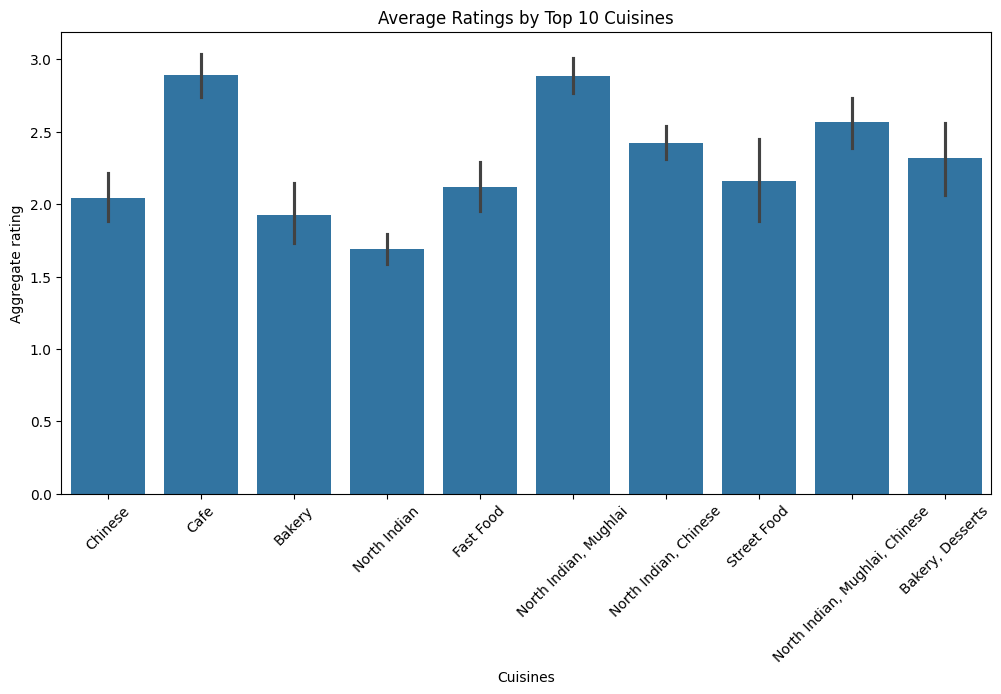

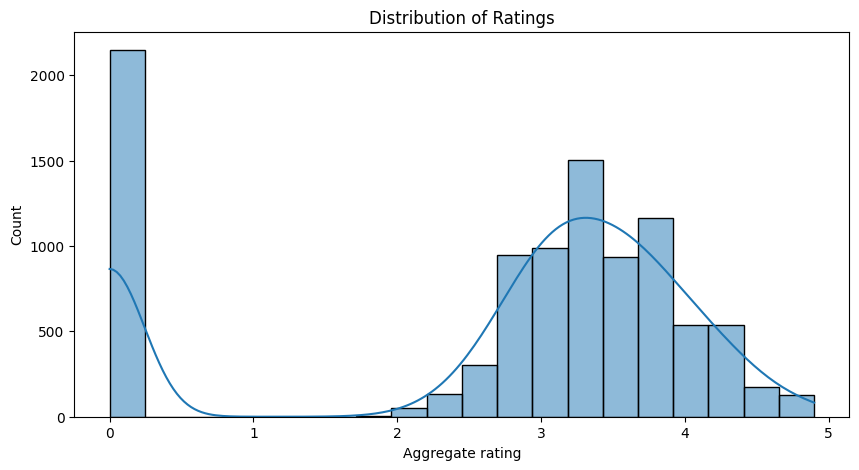

In [ ]:
# Task 2 & 3: Customer Preference Analysis & Data Visualization
if "Cuisines" in df.columns and "Aggregate rating" in df.columns:
    top_cuisines = df["Cuisines"].value_counts().head(10).index
    plt.figure(figsize=(12,6))
    sns.barplot(data=df[df["Cuisines"].isin(top_cuisines)], x="Cuisines", y="Aggregate rating")
    plt.title("Average Ratings by Top 10 Cuisines")
    plt.xticks(rotation=45)
    plt.show()

if "Aggregate rating" in df.columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df["Aggregate rating"], bins=20, kde=True)
    plt.title("Distribution of Ratings")
    plt.show()